# Importação de bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Configurando tema para os gráficos

In [2]:
sns.set_theme(style='white',palette='Set2')

# Tema 2: Óbitos por Causas Evitáveis no Brasil por Faixa Etária

## Objetivo
Identificar quais faixas etárias e *regiões* apresentam mais óbitos evitáveis

OBS: Não há regiões no dataset


# Perguntas
1. Identificar quais faixas etárias e regiões apresentam mais óbitos evitáveis. R: Não há regioes no dataset, considerando todo o dataset a faixa 40-49 é o que mais tem óbitos
2. (plus) Identificar ano com mais óbitos
R: Ano 2020 Apresenta maior numero de óbtios
3.(plus) Período da Pandemia covid-19 apresentou alguma alta nos números ?
R: Não
4.(plus) Há alguma correlação entre faixa etaria e numero de óbitos ?
R: S
5. Qual grupo mais vulnerável ?
R: 40-49 anos e 60-69, ou seja a população mais idosa.


# Análise exploratória dos dados (EDA)

In [3]:
df_obitos = pd.read_excel('Simulacao_Obitos_Causas_Evitaveis_2015_2024.xlsx')
df_obitos.head()

,Ano,Faixa Etária,Óbitos por Causas Evitáveis
0,2015,0-4 anos,1176
1,2015,5-9 anos,1509
2,2015,10-14 anos,910
3,2015,15-19 anos,1344
4,2015,20-29 anos,1180


In [4]:
df_obitos.tail()

,Ano,Faixa Etária,Óbitos por Causas Evitáveis
95,2024,30-39 anos,1550
96,2024,40-49 anos,752
97,2024,50-59 anos,451
98,2024,60-69 anos,779
99,2024,70+ anos,1629


In [5]:
df_obitos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Ano                          100 non-null    int64 
 1   Faixa Etária                 100 non-null    object
 2   Óbitos por Causas Evitáveis  100 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 2.5+ KB


Não há dados faltantes

In [6]:
df_obitos.describe().T

,count,mean,std,min,25%,50%,75%,max
Ano,100.0,2019.50,2.886751,2015.0,2017.0,2019.5,2022.0,2024.0
Óbitos por Causas Evitáveis,100.0,1022.58,532.161652,63.0,599.0,1048.0,1469.0,1949.0


-Coluna Ano vai de 2015 a 2024 (10 anos de intervalo)
<br>
-Coluna número de Óbitos vai de 63 a 1949


In [7]:
df_obitos.describe(exclude='number')

,Faixa Etária
count,100
unique,10
top,0-4 anos
freq,10


Faixa Etária esta dividida em 10 bins

In [8]:
df_obitos['Ano'].unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

In [9]:
df_obitos['Faixa Etária'].unique()

array(['0-4 anos', '5-9 anos', '10-14 anos', '15-19 anos', '20-29 anos',
       '30-39 anos', '40-49 anos', '50-59 anos', '60-69 anos', '70+ anos'],
      dtype=object)

## Fim do EDA
Não há dados faltantes
Dados não apresentam erros de grafia,numero etc
Dataset pronto para analise gráfica

In [10]:
df_obitos_gb_ano_obitos=df_obitos.groupby('Ano')['Óbitos por Causas Evitáveis'].sum()
df_obitos_gb_faixa_obitos=df_obitos.groupby('Faixa Etária')['Óbitos por Causas Evitáveis'].sum()

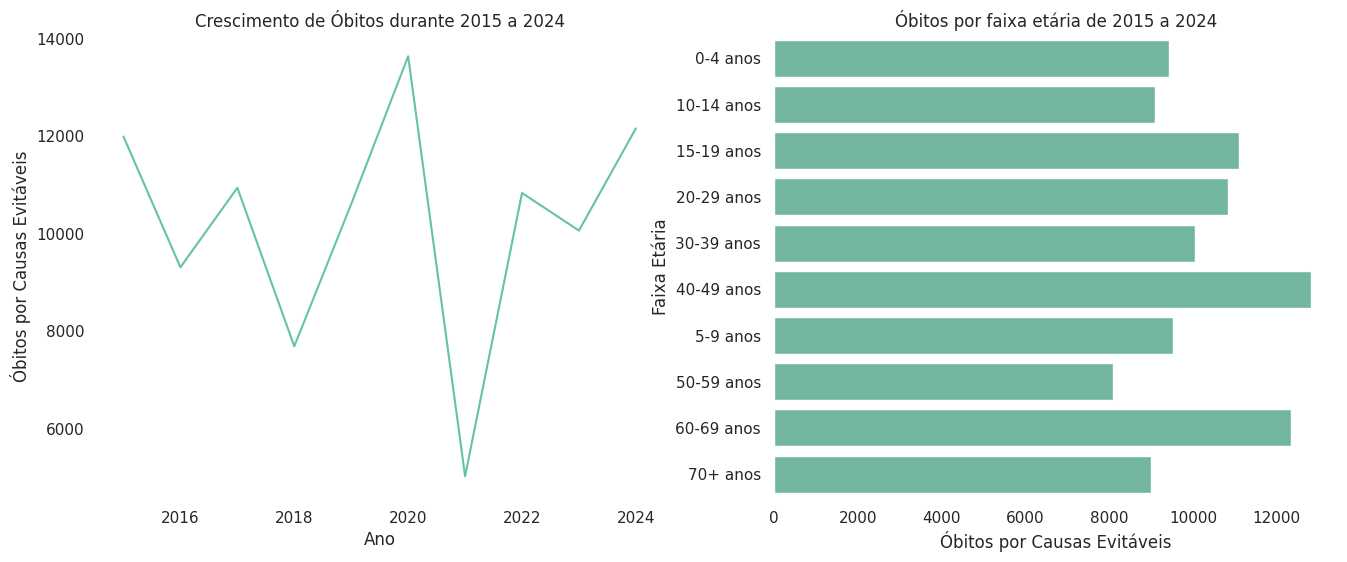

In [20]:
fig, axs = plt.subplots(nrows=1,ncols=2, figsize=(16,6))


sns.lineplot(x=df_obitos_gb_ano_obitos.index,y=df_obitos_gb_ano_obitos,ax=axs[0])

sns.barplot(x=df_obitos_gb_faixa_obitos,y=df_obitos_gb_faixa_obitos.index,ax=axs[1],orient='h')
axs[0].set_frame_on(False)
axs[0].set_title('Crescimento de Óbitos durante 2015 a 2024')
axs[1].set_frame_on(False)
axs[1].set_title('Óbitos por faixa etária de 2015 a 2024')

plt.show()

Considerando todo o intervalo de 2015 a 2024
O Ano de 2020  foi o que apresentou maior alta, talvez por causa do covid-19 ?
Faixa etária que mais apresenta óbitos é de 40-49 anos


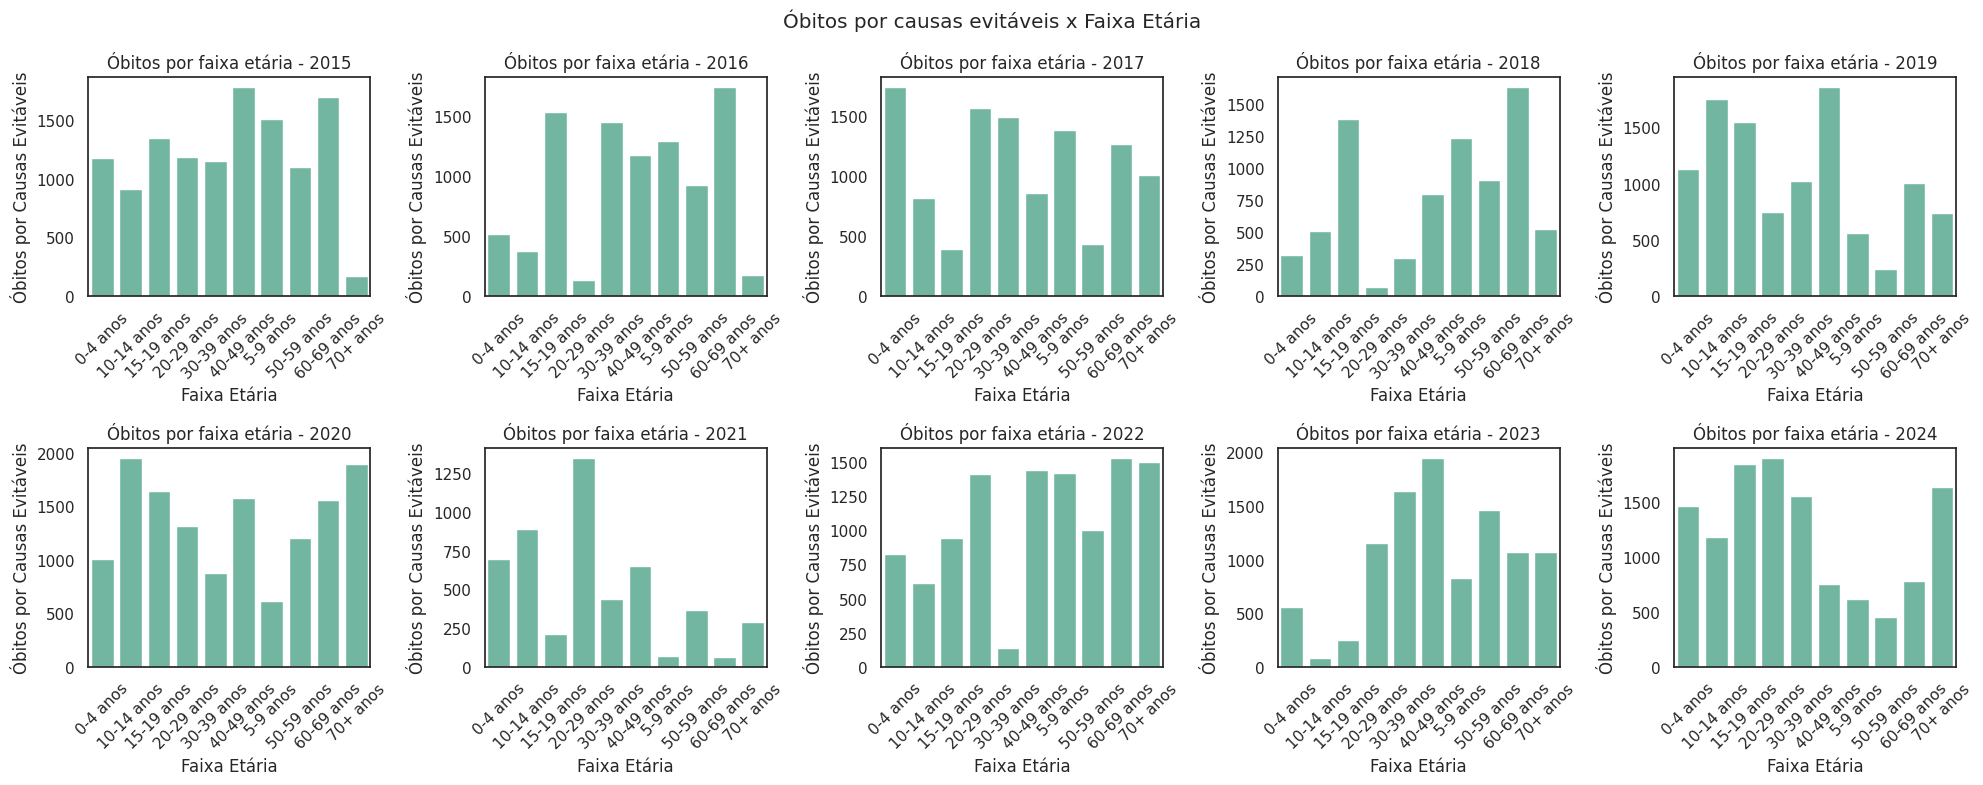

In [24]:
fig, axs = plt.subplots(ncols=5, nrows=2, figsize=(20, 8))

fig.suptitle('Óbitos por causas evitáveis x Faixa Etária')
for index, ano in enumerate(df_obitos['Ano'].unique()):
    df_filtrado = df_obitos[df_obitos['Ano'] == ano]
    df_filtrado_gb = df_filtrado.groupby('Faixa Etária', as_index=False)['Óbitos por Causas Evitáveis'].sum()

    ax = axs.flatten()[index]
    sns.barplot(data=df_filtrado_gb, x='Faixa Etária', y='Óbitos por Causas Evitáveis', ax=ax)
    ax.set_title(f'Óbitos por faixa etária - {ano}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



Ano de 2015 -
Mais óbitos: 40-49 Anos
Menos óbitos:70+
<br>
Ano de 2016 -
Mais óbitos: 60-69 Anos
Menos óbitos:15-19

O restante dos anos segue variando muito, não observo nenhum padrão. Talvez se tivesse uma coluna indicando a região. Também não observei relação com periodo de pandemia 2020-2021


O Ano de 2020 confirmando a analise inicial é o que apresenta maior concentração de óbitos uma possivel justificativa seria a Pandemia ter afetado porém observa-se uma notável queda em 2021 ano que teve maior pico de infectados durante a pandemia. Portanto a causa do óbito não tem relação com pandemia.

<Axes: xlabel='Ano', ylabel='Óbitos por Causas Evitáveis'>

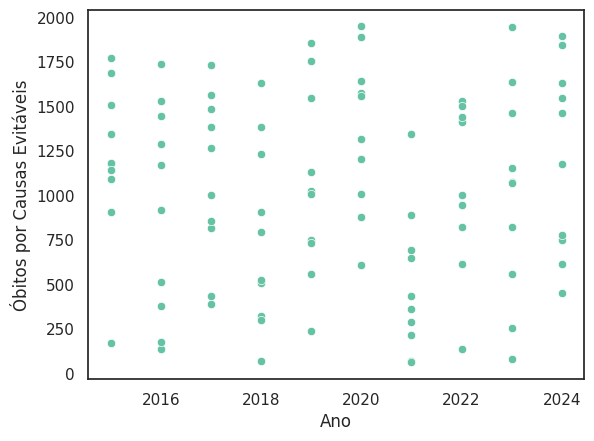

In [27]:
sns.scatterplot(x='Ano',y='Óbitos por Causas Evitáveis',data=df_obitos)

Não há correlação entre ano e numero de óbitos por causas evitaveis

# Conclusão
A análise ano a ano nesse dataset não apresenta uma interpretação notável, pois tem ano que uma faixa etaria se sobressai sobre a outra e vice versa. Nehuma relação tambem de melhora das condições durante o anos.
O que da para afirmar é que em números absolutos a população de 40-49 anos e 60-69 anos foram as que mais apresentaram óbitos por causas evitáveis. Talvez uma possivel causa seja doenças crônicas em idosos talvez diabetes e pressao alta. Porém necessito de mais dados para levantar hipóteses mais concretas sobre o motivo



<Axes: xlabel='Ano', ylabel='Óbitos por Causas Evitáveis'>

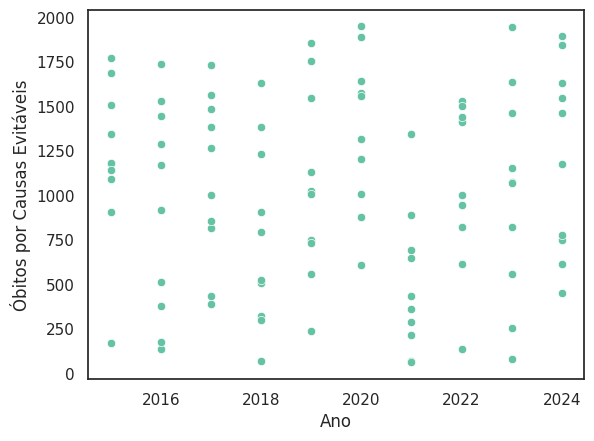